In [1]:
import numpy as np
import scprep
import phate
import matplotlib

/home/aarthivenkat/.local/lib/python3.8/site-packages/pandas/core/computation/expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## Generate Splatter simulated data, linear trajectory

In [21]:
sim = scprep.run.splatter.SplatSimulate(method='paths', dropout_type='binomial', dropout_prob=0.95,
                                        batch_cells=10000, seed=42,path_length=10000)

# number of cells with measurement of gene
gene_mask = (sim['counts'] > 0).sum(axis=0) > 50
# remove lowly expressed genes
data_expressed_genes = sim['counts'][:, gene_mask]

data_libnorm = scprep.normalize.library_size_normalize(data_expressed_genes)
data_libnorm_sqrt = scprep.transform.sqrt(data_libnorm)

/home/aarthivenkat/.local/lib/python3.8/site-packages/scprep/run/splatter.py:291: FutureWarning: path_length has been renamed path_n_steps, please use path_n_steps in the future.
  warnings.warn(
R[write to console]: Getting parameters...
R[write to console]: Creating simulation object...
R[write to console]: Simulating library sizes...
R[write to console]: Simulating gene means...
R[write to console]: Simulating path endpoints...
R[write to console]: Simulating path steps...
R[write to console]: Simulating BCV...
R[write to console]: Simulating counts...
R[write to console]: Simulating dropout (if needed)...
R[write to console]: Sparsifying assays...
R[write to console]: Automatically converting to sparse matrices, threshold = 0.95
R[write to console]: Skipping 'BatchCellMeans': estimated sparse size 1.5 * dense matrix
R[write to console]: Skipping 'BaseCellMeans': estimated sparse size 1.5 * dense matrix
R[write to console]: Skipping 'BCV': estimated sparse size 1.5 * dense matrix
R[

In [23]:
data_expressed_genes_true = sim['true_counts'][:, gene_mask]
data_libnorm_true = scprep.normalize.library_size_normalize(data_expressed_genes_true)
data_libnorm_sqrt_true = scprep.transform.sqrt(data_libnorm_true)

In [ ]:
np.savez('./data/splatter_simulated_data.npz',
         data=data_libnorm_sqrt,
         pseudotime=sim['step'],
         true_counts=data_libnorm_sqrt_true)

### Generated localization test signals

In [8]:
trajectory_data = np.load('./data/splatter_simulated_data.npz')
pseudotime = trajectory_data['pseudotime'] / 10000

In [25]:
signals = []
spread = []
for i in range(50):
    for window in np.linspace(0.2, 1, 5):
        pseudotime_range = (window/2, (1-(window/2)))
        sample_mean = np.random.choice(np.linspace(window/2, (1-(window/2)), num=1000), size=1)[0]
        cell_group = (pseudotime >= (sample_mean - (window/2))) & (pseudotime < (sample_mean + (window/2)))
        cell_samples = np.random.choice(np.where(cell_group)[0], size=500, replace=False)
        signal = np.zeros(len(pseudotime))
        signal[cell_samples] = 1
        signals.append(signal)
        spread.append(window)
        
signals = np.array(signals)
spread = np.array(spread)

np.savez_compressed('./data/localization_signals.npz', signals=signals, spread=spread)

### Pseudotime

In [3]:
sim = np.load('./data/splatter_simulated_data.npz')

In [4]:
phate_op = phate.PHATE(random_state=42)
data_phate = phate_op.fit_transform(sim['data'])

Calculating PHATE...
  Running PHATE on 10000 observations and 8821 variables.
  Calculating graph and diffusion operator...
    Calculating PCA...
    Calculated PCA in 5.86 seconds.
    Calculating KNN search...
    Calculated KNN search in 9.82 seconds.
    Calculating affinities...
    Calculated affinities in 8.42 seconds.
  Calculated graph and diffusion operator in 24.14 seconds.
  Calculating landmark operator...
    Calculating SVD...
    Calculated SVD in 2.19 seconds.
    Calculating KMeans...
    Calculated KMeans in 3.12 seconds.
  Calculated landmark operator in 6.74 seconds.
  Calculating optimal t...
    Automatically selected t = 5
  Calculated optimal t in 1.85 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.39 seconds.
  Calculating metric MDS...
  Calculated metric MDS in 4.25 seconds.
Calculated PHATE in 37.38 seconds.


In [5]:
cmap = matplotlib.colors.LinearSegmentedColormap.from_list('',["snow",'#216E76'])

<AxesSubplot:title={'center':'Pseudotime'}>

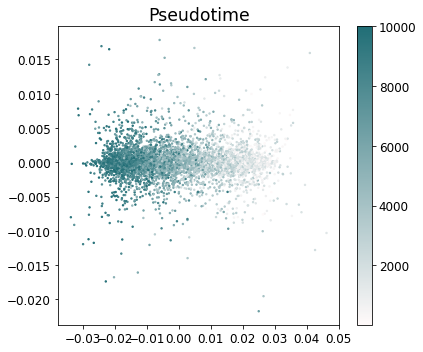

In [7]:
scprep.plot.scatter2d(data_phate, c=sim['pseudotime'], cmap=cmap, figsize=(6,5),
                      filename='splatter_simulated_data.png', dpi=200, title='Pseudotime')

## Generate Splatter simulated data, multiple branches

In [79]:
n_branches = 3

In [80]:
sim = scprep.run.splatter.SplatSimulate(method='paths', dropout_type='binomial', dropout_prob=0.95, bcv_common=0.5,
                                        batch_cells=10000, seed=42,path_length=10000, 
                                        group_prob=[1/n_branches]*n_branches, path_from=[0]*n_branches)

/home/aarthivenkat/.local/lib/python3.8/site-packages/scprep/run/splatter.py:291: FutureWarning: path_length has been renamed path_n_steps, please use path_n_steps in the future.
  warnings.warn(
R[write to console]: Getting parameters...
R[write to console]: Creating simulation object...
R[write to console]: Simulating library sizes...
R[write to console]: Simulating gene means...
R[write to console]: Simulating path endpoints...
R[write to console]: Simulating path steps...
R[write to console]: Simulating BCV...
R[write to console]: Simulating counts...
R[write to console]: Simulating dropout (if needed)...
R[write to console]: Sparsifying assays...
R[write to console]: Automatically converting to sparse matrices, threshold = 0.95
R[write to console]: Skipping 'BatchCellMeans': estimated sparse size 1.5 * dense matrix
R[write to console]: Skipping 'BaseCellMeans': estimated sparse size 1.5 * dense matrix
R[write to console]: Skipping 'BCV': estimated sparse size 1.5 * dense matrix
R[

In [81]:
# number of cells with measurement of gene
gene_mask = (sim['counts'] > 0).sum(axis=0) > 50
# remove lowly expressed genes
data_expressed_genes = sim['counts'][:, gene_mask]

data_libnorm = scprep.normalize.library_size_normalize(data_expressed_genes)
data_libnorm_sqrt = scprep.transform.sqrt(data_libnorm)

In [82]:
data_expressed_genes_true = sim['true_counts'][:, gene_mask]
data_libnorm_true = scprep.normalize.library_size_normalize(data_expressed_genes_true)
data_libnorm_sqrt_true = scprep.transform.sqrt(data_libnorm_true)

In [83]:
np.savez(f'./data/splatter_simulated_data_{n_branches}_branches.npz',
         data=data_libnorm_sqrt,
         pseudotime=sim['step'],
         true_counts=data_libnorm_sqrt_true)

## Pseudotime

In [84]:
sim = np.load(f'./data/splatter_simulated_data_{n_branches}_branches.npz')

In [85]:
phate_op = phate.PHATE(random_state=42)
data_phate = phate_op.fit_transform(sim['data'])

Calculating PHATE...
  Running PHATE on 10000 observations and 8823 variables.
  Calculating graph and diffusion operator...
    Calculating PCA...
    Calculated PCA in 5.27 seconds.
    Calculating KNN search...
    Calculated KNN search in 9.11 seconds.
    Calculating affinities...
    Calculated affinities in 8.24 seconds.
  Calculated graph and diffusion operator in 22.65 seconds.
  Calculating landmark operator...
    Calculating SVD...
    Calculated SVD in 1.91 seconds.
    Calculating KMeans...
    Calculated KMeans in 3.74 seconds.
  Calculated landmark operator in 6.96 seconds.
  Calculating optimal t...
    Automatically selected t = 5
  Calculated optimal t in 1.91 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.32 seconds.
  Calculating metric MDS...
  Calculated metric MDS in 5.81 seconds.
Calculated PHATE in 37.66 seconds.


<AxesSubplot:title={'center':'Pseudotime'}>

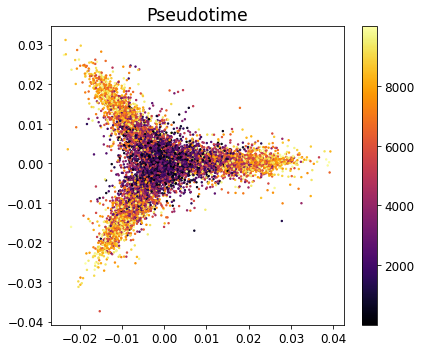

In [86]:
scprep.plot.scatter2d(data_phate, c=sim['pseudotime'], cmap='inferno', figsize=(6,5),
                      filename=f'data/splatter_simulated_data_{n_branches}_branches.png', dpi=200, title='Pseudotime')

## Generated localization test signals

In [87]:
trajectory_data = np.load(f'./data/splatter_simulated_data_{n_branches}_branches.npz')
pseudotime = trajectory_data['pseudotime'] / 10000

In [88]:
signals = []
spread = []
for i in range(50):
    for window in np.linspace(0.2, 1, 5):
        pseudotime_range = (window/2, (1-(window/2)))
        sample_mean = np.random.choice(np.linspace(window/2, (1-(window/2)), num=1000), size=1)[0]
        cell_group = (pseudotime >= (sample_mean - (window/2))) & (pseudotime < (sample_mean + (window/2)))
        cell_samples = np.random.choice(np.where(cell_group)[0], size=500, replace=False)
        signal = np.zeros(len(pseudotime))
        signal[cell_samples] = 1
        signals.append(signal)
        spread.append(window)
        
signals = np.array(signals)
spread = np.array(spread)

np.savez_compressed(f'./data/localization_signals_{n_branches}_branches.npz', signals=signals, spread=spread)